# 🔎 Exploratory Data Analysis (EDA) — Complete Data Investigation Workflow

> **Step 2: Data Science**
>
> **Topic 06: Exploratory Data Analysis**
>
> **Date: February 11, 2024** 🎯
>
> **Class 22 — Exploratory Data Analysis (EDA) Workflow**

---
# 🎯 Learning Objectives

By the end of this notebook you should be able to run a complete, question-driven EDA: understand and inspect a dataset, check quality, do univariate / bivariate / multivariate analysis, analyze distributions, outliers, correlations, groups and missing values, write insights, and know how EDA connects to Machine Learning (including data leakage).

---
# 📌 What is EDA?

**Exploratory Data Analysis (EDA)** is the process of exploring, understanding, summarizing, and visualizing a dataset before making conclusions or building Machine Learning models.

> **EDA means asking questions about your data and using statistics + visualization to find the answers.**

For a student dataset (`Student, Age, Gender, Study Hours, Attendance, Marks`), EDA helps you discover: who performs better, whether study time is related to marks, whether attendance affects performance, the average mark, unusual values, missing values, related variables, and patterns or trends.

---
# 🧠 The Simple EDA Mental Model

```text
Raw Data → Understand → Clean → Explore → Visualize → Analyze → Find Patterns → Generate Insights → Prepare for ML
```

### ⭐ Golden Rule

> **EDA is not just making charts.**

```text
EDA
├── Data Understanding
├── Data Quality Checking
├── Statistics
├── Visualization
├── Relationship Analysis
├── Pattern Detection
├── Outlier Detection
└── Insight Generation
```

---
# 🎯 Why is EDA Important?

A dataset can look simple but contain hidden problems (e.g. `Age: 20, 21, 22, 23, 250`). Without EDA, you may train a model on incorrect data. EDA helps you discover missing values, duplicates, outliers, incorrect values, distributions, relationships, correlations, trends, imbalanced categories, potential data leakage and important features.

---
# 🔄 Complete EDA Workflow

```text
Dataset
  ↓  1. Understand Dataset
  ↓  2. Inspect Structure
  ↓  3. Check Data Quality
  ↓  4. Clean Data
  ↓  5. Univariate Analysis
  ↓  6. Bivariate Analysis
  ↓  7. Multivariate Analysis
  ↓  8. Statistical Analysis
  ↓  9. Detect Patterns
  ↓ 10. Find Relationships
  ↓ 11. Generate Insights
  ↓ 12. Document Findings
ML / Decision Making
```

---
# 1️⃣ Understand the Problem

Before opening Pandas, ask:

* **What is the dataset about?** → *Student Performance Dataset*
* **What does each row represent?** → *One row = One student*
* **What does each column represent?** → `Age` (student age), `Gender`, `Study_Hours` (daily study hours), `Marks` (exam marks)
* **What are you trying to discover?** → *What factors are associated with student performance?*

This question guides your EDA.

---
# 2️⃣ Load the Dataset

The README loads `students.csv`. To keep this notebook self-contained, the next cell **generates a realistic student dataset** (with a few deliberate data-quality problems for us to find) and saves it as `students.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.width", 120)

rng = np.random.default_rng(22)
n = 300

students = pd.DataFrame({
    "Student_ID": range(1, n + 1),
    "Name": [f"Student_{i}" for i in range(1, n + 1)],
    "Age": rng.integers(18, 26, n).astype(float),
    "Gender": rng.choice(["Male", "Female"], n),
    "City": rng.choice(["Islamabad", "Lahore", "Karachi", "Peshawar"], n, p=[0.4, 0.3, 0.2, 0.1]),
})
students["Study_Hours"] = rng.gamma(4, 0.9, n).clip(0.5, 10).round(1)
students["Attendance"] = rng.normal(82, 10, n).clip(40, 100).round(1)
students["Previous_Marks"] = rng.normal(62, 13, n).clip(15, 100).round(1)
students["Final_Marks"] = (
    0.45 * students["Previous_Marks"]
    + 3.2 * students["Study_Hours"]
    + 0.25 * students["Attendance"]
    + rng.normal(0, 5, n)
).clip(0, 100).round(1)

# ---- deliberate problems for EDA to discover ----
students.loc[[10, 60, 120, 200], "Age"] = np.nan
students.loc[[15, 90], "Attendance"] = np.nan
students.loc[[33], "Age"] = 250                                # impossible value
students.loc[[77], "Study_Hours"] = 15.5                       # unusual value
students = pd.concat([students, students.iloc[[0, 1]]], ignore_index=True)   # 2 duplicates

students.to_csv("students.csv", index=False)

df = pd.read_csv("students.csv")

df.head()

,Student_ID,Name,Age,Gender,City,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,1,Student_1,24.0,Male,Peshawar,1.1,83.5,82.6,63.5
1,2,Student_2,20.0,Male,Islamabad,1.9,79.1,54.7,61.0
2,3,Student_3,23.0,Female,Lahore,3.2,94.4,77.8,67.3
3,4,Student_4,19.0,Female,Peshawar,1.2,82.9,70.2,52.8
4,5,Student_5,25.0,Male,Lahore,0.5,74.2,60.3,51.5


---
# 3️⃣ Inspect Dataset Structure

`df.shape` → e.g. `(1000, 8)` means 1000 rows, 8 columns. Also check `df.columns`, `df.dtypes`, `df.info()`.

In [2]:
print("Shape  :", df.shape)
print("Columns:", list(df.columns))
print()
print(df.dtypes)
df.info()

Shape  : (302, 9)
Columns: ['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Final_Marks']

Student_ID          int64
Name                  str
Age               float64
Gender                str
City                  str
Study_Hours       float64
Attendance        float64
Previous_Marks    float64
Final_Marks       float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      302 non-null    int64  
 1   Name            302 non-null    str    
 2   Age             298 non-null    float64
 3   Gender          302 non-null    str    
 4   City            302 non-null    str    
 5   Study_Hours     302 non-null    float64
 6   Attendance      300 non-null    float64
 7   Previous_Marks  302 non-null    float64
 8   Final_Marks     302 non-null    float64
dtypes: float64(5), int64(

---
# 4️⃣ Preview the Data

| Function   | Purpose        |
| ---------- | -------------- |
| `head()`   | Beginning      |
| `tail()`   | End            |
| `sample()` | Random records |

Random sampling is particularly useful because problems aren't always located at the beginning of a dataset.

In [3]:
display(df.head(3))
display(df.tail(3))
df.sample(5, random_state=1)

,Student_ID,Name,Age,Gender,City,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,1,Student_1,24.0,Male,Peshawar,1.1,83.5,82.6,63.5
1,2,Student_2,20.0,Male,Islamabad,1.9,79.1,54.7,61.0
2,3,Student_3,23.0,Female,Lahore,3.2,94.4,77.8,67.3


,Student_ID,Name,Age,Gender,City,Study_Hours,Attendance,Previous_Marks,Final_Marks
299,300,Student_300,21.0,Female,Karachi,3.3,98.4,57.7,55.6
300,1,Student_1,24.0,Male,Peshawar,1.1,83.5,82.6,63.5
301,2,Student_2,20.0,Male,Islamabad,1.9,79.1,54.7,61.0


,Student_ID,Name,Age,Gender,City,Study_Hours,Attendance,Previous_Marks,Final_Marks
173,174,Student_174,25.0,Female,Lahore,3.4,70.1,75.5,56.4
88,89,Student_89,19.0,Female,Peshawar,4.3,73.2,57.0,61.4
163,164,Student_164,20.0,Female,Islamabad,2.3,80.7,70.6,64.4
242,243,Student_243,22.0,Male,Lahore,6.3,97.8,51.7,63.2
110,111,Student_111,19.0,Female,Islamabad,3.3,86.5,67.8,65.3


---
# 5️⃣ Understand Numerical Data

`df.describe()` gives count, mean, std, min, 25%, 50%, 75%, max — helping you understand central tendency, spread, minimum, maximum and potential outliers.

In [4]:
df.describe().round(2)

,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Final_Marks
count,302.00,298.00,302.00,300.00,302.00,302.00
mean,149.51,22.31,3.58,82.08,62.77,60.26
std,87.30,13.43,1.85,9.46,12.84,9.64
min,1.00,18.00,0.50,54.00,15.00,31.30
25%,74.25,20.00,2.20,74.90,53.80,54.40
50%,149.50,21.50,3.30,82.55,62.60,60.05
75%,224.75,23.00,4.50,88.43,71.88,67.00
max,300.00,250.00,15.50,100.00,100.00,90.10


👀 Notice `Age max = 250` and `Study_Hours max = 15.5` — suspicious already. Let's keep investigating.

---
# 6️⃣ Understand Categorical Data

What categories exist and how frequently do they occur?

In [5]:
print(df["Gender"].value_counts())
print()
print(df["Gender"].unique())
print("Unique genders:", df["Gender"].nunique())
print()
print(df["City"].value_counts(normalize=True).round(3))

Gender
Female    154
Male      148
Name: count, dtype: int64

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
Unique genders: 2

City
Islamabad    0.421
Lahore       0.291
Karachi      0.199
Peshawar     0.089
Name: proportion, dtype: float64


---
# 7️⃣ Check Data Quality

Before analyzing patterns: missing values, duplicates, data types, suspicious values.

```text
EDA → Find Problem → Clean Data → EDA Again → Find New Insights
```

So EDA is often **iterative**, not strictly one-directional.

In [6]:
print("Missing values:\n", df.isnull().sum(), "\n")
print("Duplicates:", df.duplicated().sum())
print("\nSuspicious values:")
display(df["Age"].describe())
display(df[(df["Age"] > 100) | (df["Study_Hours"] > 12)])

Missing values:
 Student_ID        0
Name              0
Age               4
Gender            0
City              0
Study_Hours       0
Attendance        2
Previous_Marks    0
Final_Marks       0
dtype: int64 

Duplicates: 2

Suspicious values:


count    298.000000
mean      22.312081
std       13.427443
min       18.000000
25%       20.000000
50%       21.500000
75%       23.000000
max      250.000000
Name: Age, dtype: float64

,Student_ID,Name,Age,Gender,City,Study_Hours,Attendance,Previous_Marks,Final_Marks
33,34,Student_34,250.0,Female,Lahore,6.6,85.1,51.3,59.5
77,78,Student_78,19.0,Female,Islamabad,15.5,94.3,43.6,50.5


### Clean (briefly) so the rest of the EDA is trustworthy

In [7]:
raw = df.copy()                       # keep the raw data safe

df = df.drop_duplicates().reset_index(drop=True)
df.loc[df["Age"] > 100, "Age"] = np.nan            # impossible -> missing
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].median())

print("Rows: raw", len(raw), "-> clean", len(df))
print("Missing left:", df.isnull().sum().sum(), "| Duplicates left:", df.duplicated().sum())

Rows: raw 302 -> clean 300
Missing left: 0 | Duplicates left: 0


> The study-hours value `15.5` is **unusual but not impossible**, so we keep it and will look at it again in outlier analysis. *(Unusual ≠ wrong.)*

---
# 8️⃣ Univariate Analysis

**Uni = One** — analyzing one variable at a time. Questions: What is the distribution? The average? The most common category? Are there outliers?

## 📊 Numerical Univariate Analysis

Statistics: `mean`, `median`, `min`, `max`, `std`. Visualizations: Histogram, KDE, Box Plot.

In [8]:
print("Mean  :", round(df["Final_Marks"].mean(), 2))
print("Median:", round(df["Final_Marks"].median(), 2))
print("Min   :", df["Final_Marks"].min())
print("Max   :", df["Final_Marks"].max())
print("Std   :", round(df["Final_Marks"].std(), 2))

Mean  : 60.24
Median: 60.0
Min   : 31.3
Max   : 90.1
Std   : 9.67


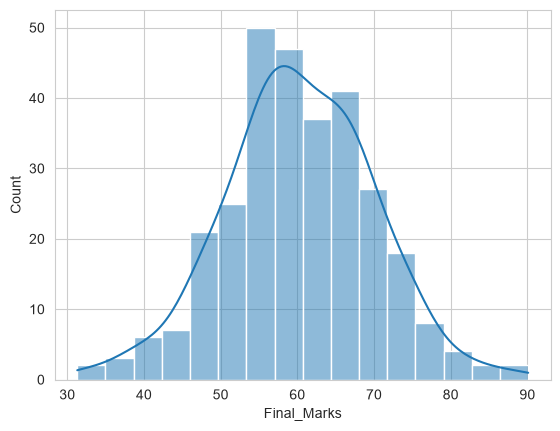

In [9]:
sns.histplot(data=df, x="Final_Marks", kde=True)

plt.show()

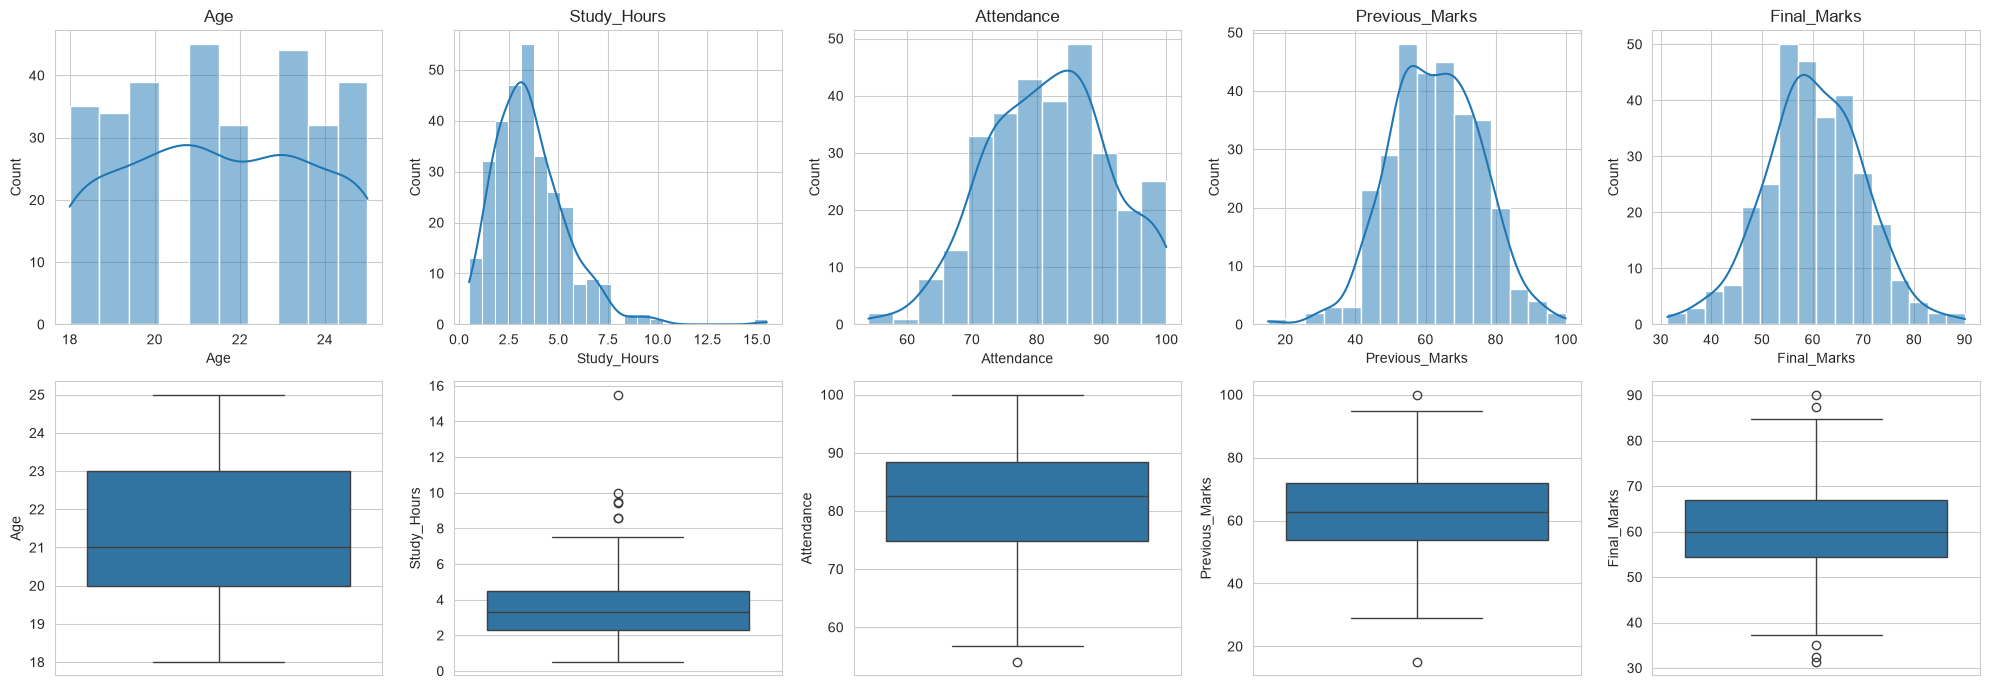

In [10]:
# All numerical columns at once: histogram (top) + box plot (bottom)
num_cols = ["Age", "Study_Hours", "Attendance", "Previous_Marks", "Final_Marks"]
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i]); axes[0, i].set_title(col)
    sns.boxplot(y=df[col], ax=axes[1, i])
plt.tight_layout()
plt.show()

---
# 9️⃣ Categorical Univariate Analysis

How are observations distributed among categories?

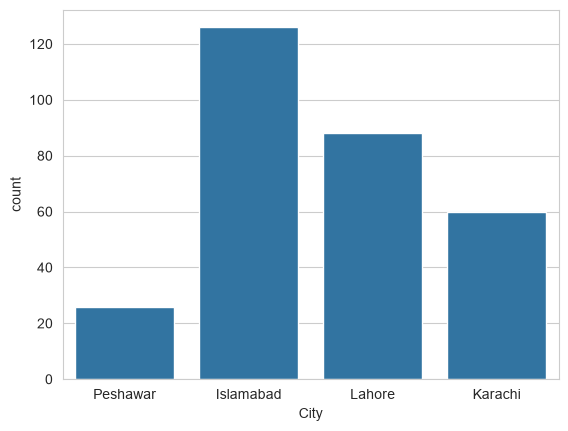

In [11]:
sns.countplot(
    data=df,
    x="City"
)

plt.show()

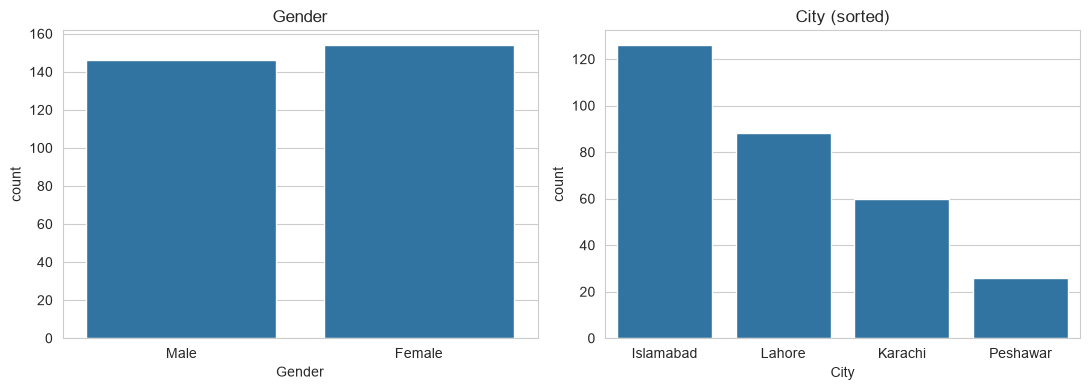

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="Gender", ax=axes[0]); axes[0].set_title("Gender")
sns.countplot(data=df, x="City", order=df["City"].value_counts().index, ax=axes[1]); axes[1].set_title("City (sorted)")
plt.tight_layout(); plt.show()

---
# 🔟 Bivariate Analysis

**Bi = Two** — relationship between two variables: Age ↔ Salary, Study Hours ↔ Marks, Experience ↔ Salary, Gender ↔ Marks.

## 🔵 Numerical + Numerical

> Do students who study more tend to have higher marks?

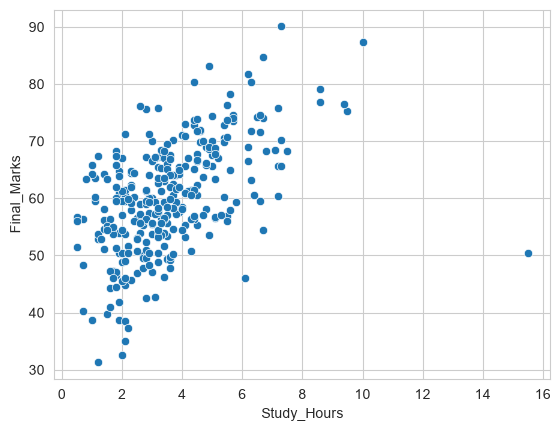

In [13]:
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Marks"
)

plt.show()

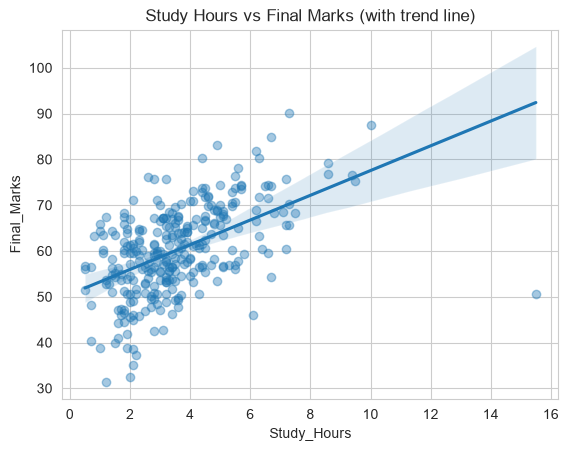

Correlation: 0.516


In [14]:
sns.regplot(data=df, x="Study_Hours", y="Final_Marks", scatter_kws={"alpha": 0.4})
plt.title("Study Hours vs Final Marks (with trend line)")
plt.show()

print("Correlation:", round(df["Study_Hours"].corr(df["Final_Marks"]), 3))

---
# 1️⃣1️⃣ Numerical + Categorical

Example: Department → Salary, Gender → Marks. Use box plots or bar plots.

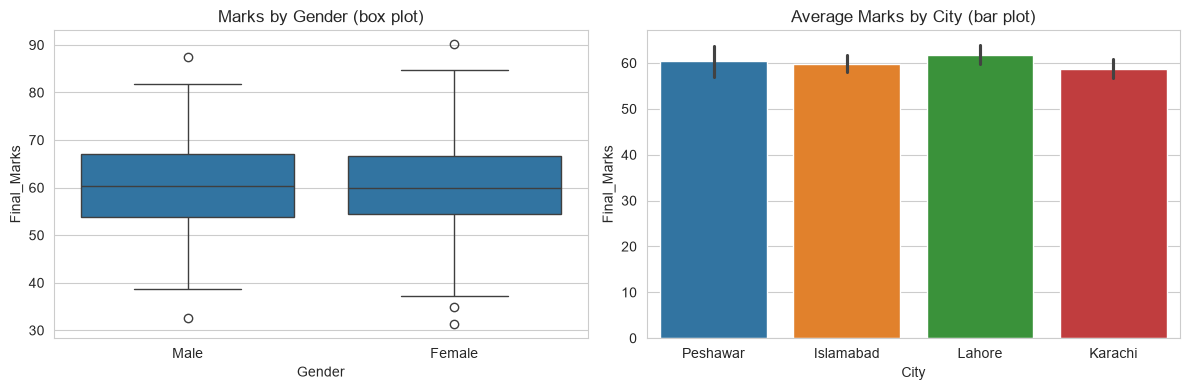

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="Gender", y="Final_Marks", ax=axes[0])
sns.barplot(data=df, x="City", y="Final_Marks", hue="City", legend=False, ax=axes[1])
axes[0].set_title("Marks by Gender (box plot)")
axes[1].set_title("Average Marks by City (bar plot)")
plt.tight_layout(); plt.show()

The README's `Department → Salary` example needs an employee dataset, so here is a small one to practise the same idea:

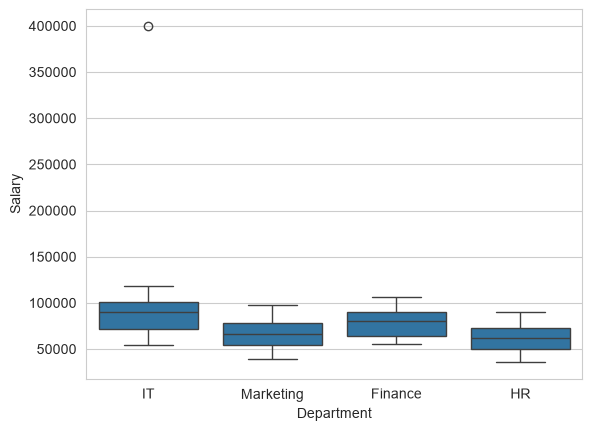

In [16]:
emp = pd.DataFrame({
    "Department": rng.choice(["IT", "Marketing", "HR", "Finance"], 200),
    "Experience": rng.integers(0, 20, 200),
})
base = emp["Department"].map({"IT": 60000, "Marketing": 45000, "HR": 40000, "Finance": 55000})
emp["Salary"] = (base + emp["Experience"] * 2500 + rng.normal(0, 7000, 200)).round(0)
emp.loc[5, "Salary"] = 400000        # one CEO-style salary

sns.boxplot(
    data=emp,
    x="Department",
    y="Salary"
)

plt.show()

---
# 1️⃣2️⃣ Categorical + Categorical

Example: Gender ↔ Department. Use `pd.crosstab()` and visualize with a heatmap.

City,Islamabad,Karachi,Lahore,Peshawar
Gender,,,,
Female,71,27,44,12
Male,55,33,44,14


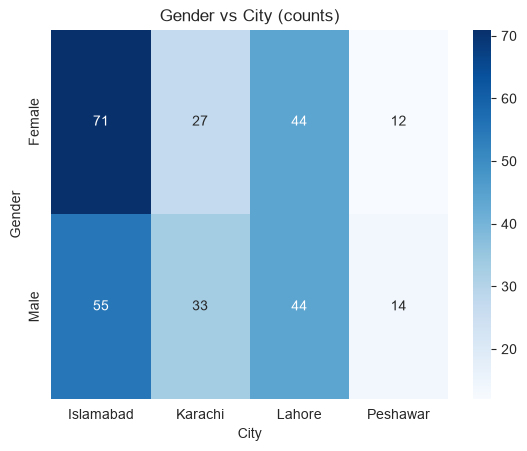

In [17]:
ct = pd.crosstab(df["Gender"], df["City"])
display(ct)

sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("Gender vs City (counts)")
plt.show()

In [18]:
# Proportions are often more informative than counts
ct_pct = pd.crosstab(df["City"], df["Gender"], normalize="index").round(3) * 100
ct_pct

Gender,Female,Male
City,,
Islamabad,56.3,43.7
Karachi,45.0,55.0
Lahore,50.0,50.0
Peshawar,46.2,53.8


---
# 1️⃣3️⃣ Multivariate Analysis

**Multi = More than two variables together.** Tools: Pair Plot, Correlation Heatmap, Grouped Analysis, Facets.

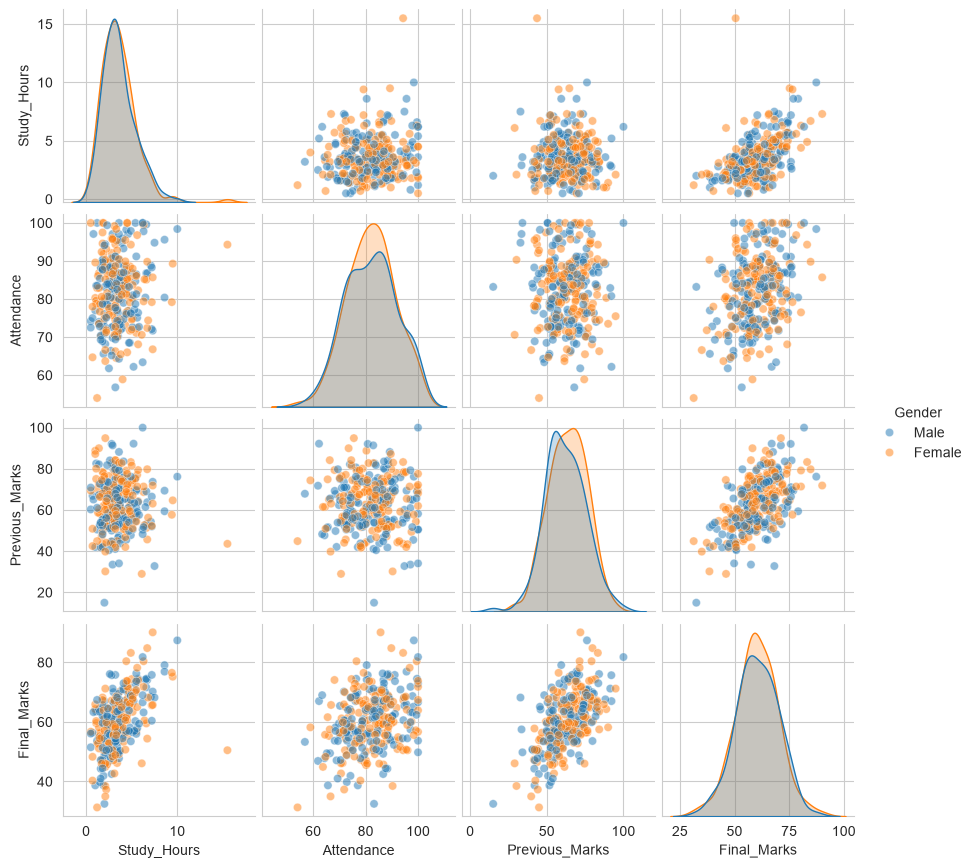

In [19]:
sns.pairplot(df[["Study_Hours", "Attendance", "Previous_Marks", "Final_Marks", "Gender"]], hue="Gender", height=2.2, plot_kws={"alpha": 0.5})
plt.show()

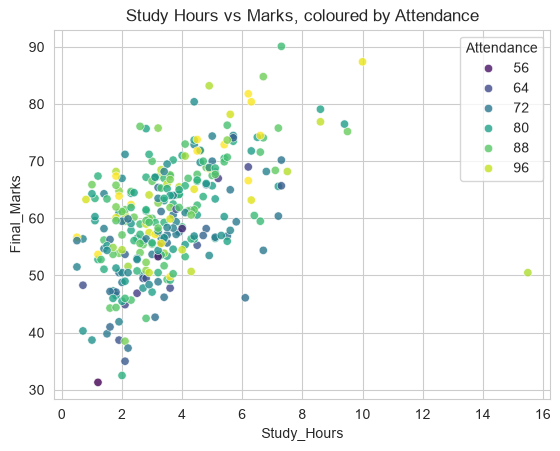

In [20]:
# Three variables in one chart: x, y and colour
sns.scatterplot(data=df, x="Study_Hours", y="Final_Marks", hue="Attendance", palette="viridis", alpha=0.8)
plt.title("Study Hours vs Marks, coloured by Attendance")
plt.show()

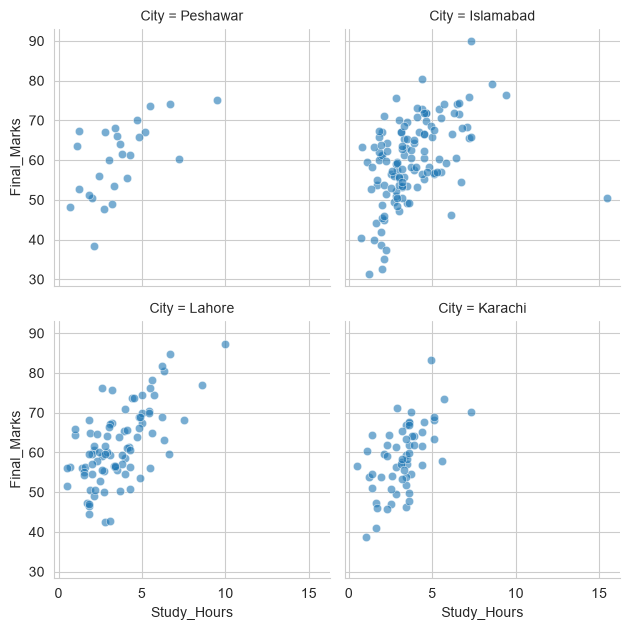

In [21]:
# Facets: one panel per group
g = sns.FacetGrid(df, col="City", col_wrap=2, height=3.2)
g.map_dataframe(sns.scatterplot, x="Study_Hours", y="Final_Marks", alpha=0.6)
plt.show()

---
# 🔗 1️⃣4️⃣ Correlation Analysis

Correlation measures the degree to which numerical variables move together. Calculate with `df.corr(numeric_only=True)` and visualize with a heatmap.

In [22]:
corr = df.corr(numeric_only=True).drop(index="Student_ID", columns="Student_ID")
corr.round(2)

,Age,Study_Hours,Attendance,Previous_Marks,Final_Marks
Age,1.00,-0.12,0.07,-0.11,-0.11
Study_Hours,-0.12,1.00,0.10,-0.02,0.52
Attendance,0.07,0.10,1.00,-0.00,0.33
Previous_Marks,-0.11,-0.02,-0.00,1.00,0.58
Final_Marks,-0.11,0.52,0.33,0.58,1.00


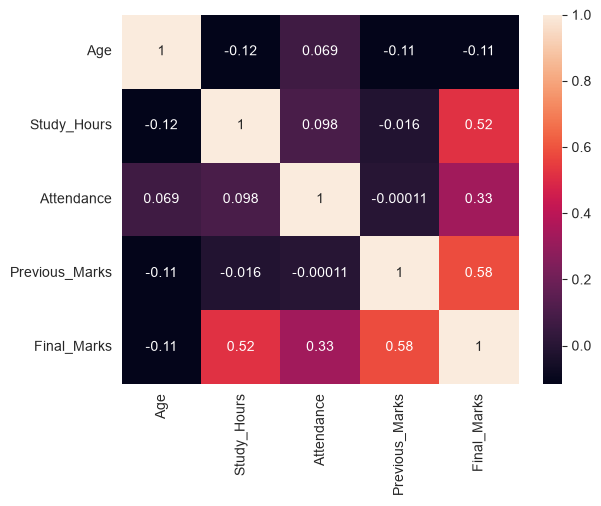

In [23]:
sns.heatmap(
    corr,
    annot=True
)

plt.show()

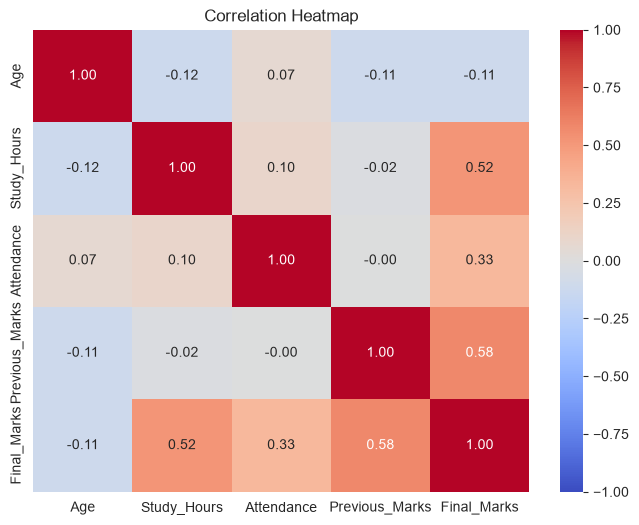

Correlation of each variable with Final_Marks:
Previous_Marks    0.582
Study_Hours       0.516
Attendance        0.328
Age              -0.109
Name: Final_Marks, dtype: float64


In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation Heatmap")
plt.show()

print("Correlation of each variable with Final_Marks:")
print(corr["Final_Marks"].drop("Final_Marks").sort_values(ascending=False).round(3))

## 📈 Positive Correlation — `Study Hours ↑ → Marks ↑` (both tend to increase together)

## 📉 Negative Correlation — `Price ↑ → Demand ↓` (one increases while the other decreases)

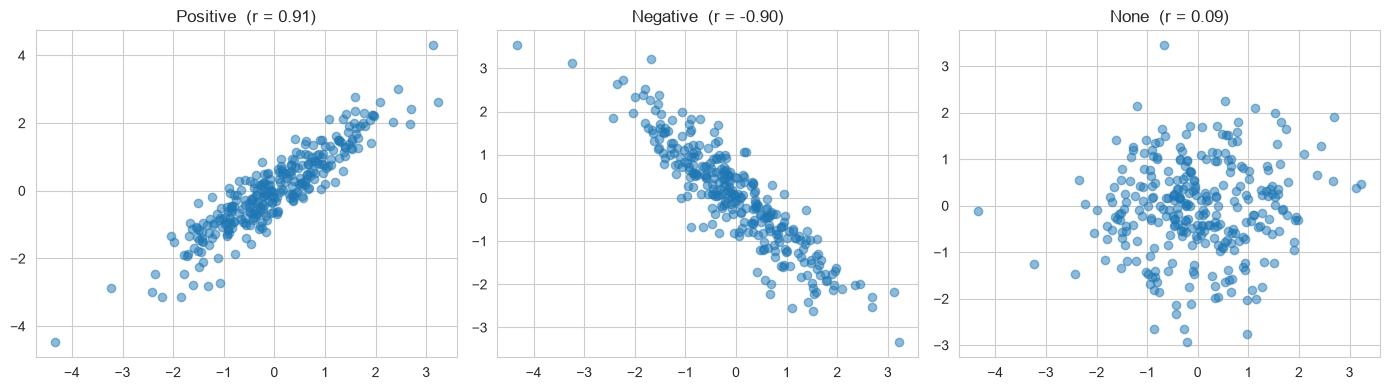

In [25]:
# Simulated illustrations of positive / negative / no correlation
x = rng.normal(0, 1, 300)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (title, y) in zip(axes, [("Positive", x + rng.normal(0, .5, 300)),
                                  ("Negative", -x + rng.normal(0, .5, 300)),
                                  ("None", rng.normal(0, 1, 300))]):
    ax.scatter(x, y, alpha=0.5)
    ax.set_title(f"{title}  (r = {np.corrcoef(x, y)[0, 1]:.2f})")
plt.tight_layout(); plt.show()

## ⚠️ Correlation Does NOT Mean Causation

If `Study Hours ↔ Marks` have a strong correlation, that does **not automatically prove** that studying more causes higher marks — other factors (prior ability, motivation, sleep…) may be involved.

> **Correlation describes an association; it does not by itself establish causation.**

Also: Pearson correlation only captures *linear* relationships, and a single outlier can distort it. Always look at the scatter plot too.

Correlation of a perfect U-shaped relationship: 0.0


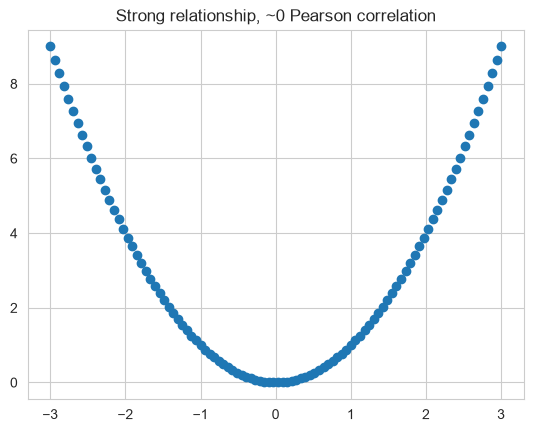

In [26]:
# Same correlation, very different pictures -> always plot!
a = np.linspace(-3, 3, 100)
b_curve = a ** 2
print("Correlation of a perfect U-shaped relationship:", round(np.corrcoef(a, b_curve)[0, 1], 3))
plt.scatter(a, b_curve); plt.title("Strong relationship, ~0 Pearson correlation"); plt.show()

---
# 1️⃣5️⃣ Distribution Analysis

Common shapes: **Normal, Right-Skewed, Left-Skewed, Uniform, Bimodal.**

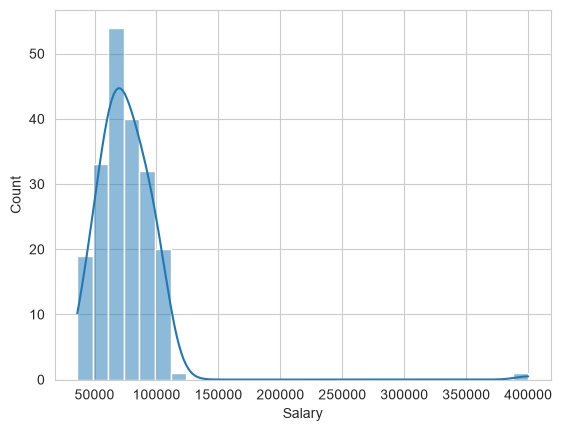

In [27]:
sns.histplot(
    data=emp,
    x="Salary",
    kde=True
)

plt.show()

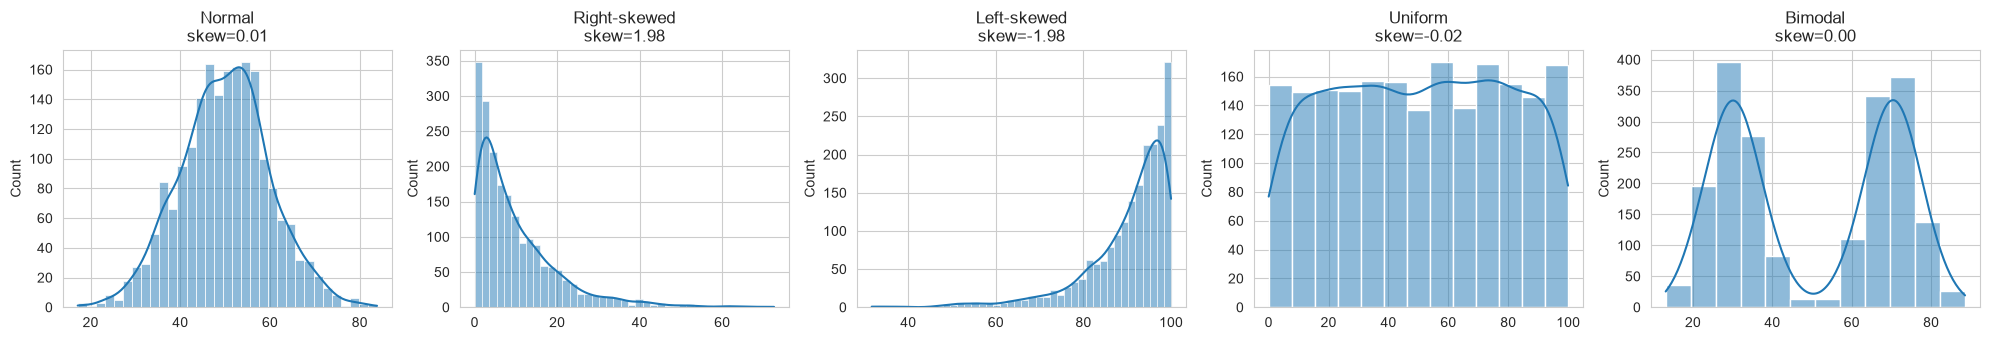

In [28]:
samples = {
    "Normal": rng.normal(50, 10, 2000),
    "Right-skewed": rng.exponential(10, 2000),
    "Left-skewed": 100 - rng.exponential(10, 2000),
    "Uniform": rng.uniform(0, 100, 2000),
    "Bimodal": np.concatenate([rng.normal(30, 6, 1000), rng.normal(70, 6, 1000)]),
}
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, (name, s) in zip(axes, samples.items()):
    sns.histplot(s, kde=True, ax=ax)
    ax.set_title(f"{name}\nskew={pd.Series(s).skew():.2f}")
plt.tight_layout(); plt.show()

In [29]:
# Skewness of our real columns
df[num_cols].skew().round(2)

Age               0.00
Study_Hours       1.53
Attendance       -0.08
Previous_Marks   -0.08
Final_Marks      -0.05
dtype: float64

---
# 1️⃣6️⃣ Detect Outliers

Use a box plot, or calculate the IQR bounds.

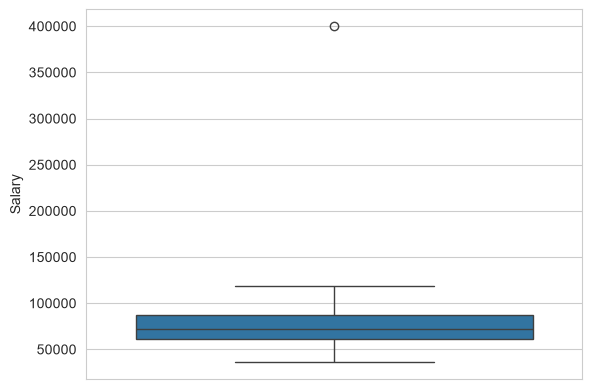

In [30]:
sns.boxplot(
    data=emp,
    y="Salary"
)

plt.show()

In [31]:
Q1 = emp["Salary"].quantile(0.25)
Q3 = emp["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = emp[
    (emp["Salary"] < lower) |
    (emp["Salary"] > upper)
]
print(f"Bounds: ({lower:,.0f}, {upper:,.0f})")
outliers

Bounds: (21,846, 126,410)


,Department,Experience,Salary
5,IT,8,400000.0


In [32]:
# Reusable: outlier summary for every numerical column of the student data
def outlier_summary(d, cols):
    rows = []
    for c in cols:
        q1, q3 = d[c].quantile([0.25, 0.75])
        i = q3 - q1
        lo, hi = q1 - 1.5 * i, q3 + 1.5 * i
        rows.append({"column": c, "lower": round(lo, 1), "upper": round(hi, 1),
                     "n_outliers": int(((d[c] < lo) | (d[c] > hi)).sum())})
    return pd.DataFrame(rows)

outlier_summary(df, num_cols)

,column,lower,upper,n_outliers
0,Age,15.5,27.5,0
1,Study_Hours,-1.1,7.8,6
2,Attendance,54.6,108.7,1
3,Previous_Marks,26.7,98.9,2
4,Final_Marks,35.2,86.1,5


Outliers are **investigated, not automatically deleted**: `Study_Hours = 15.5` is unusual — is it plausible? (If the survey asked about *weekly* hours it would be tiny; if *daily* it's near-impossible.) That's a question for the data owner.

---
# 1️⃣7️⃣ Analyze Groups

Grouping is extremely useful in EDA: Department → Average Salary, Gender → Average Marks, City → Average Sales.

In [33]:
emp.groupby("Department")["Salary"].mean().round(0)

Department
Finance      79476.0
HR           62139.0
IT           92792.0
Marketing    67046.0
Name: Salary, dtype: float64

In [34]:
df.groupby("Gender")["Final_Marks"].mean().round(2)

Gender
Female    60.16
Male      60.33
Name: Final_Marks, dtype: float64

---
# 1️⃣8️⃣ Use Multiple Statistics

Instead of only the mean, get a much better understanding:

In [35]:
emp.groupby("Department")["Salary"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
]).round(0)

,count,mean,median,min,max
Department,,,,,
Finance,44,79476.0,80363.0,54967.0,106144.0
HR,44,62139.0,62256.0,36083.0,90491.0
IT,53,92792.0,90022.0,54361.0,400000.0
Marketing,59,67046.0,66289.0,39418.0,97492.0


Notice how the mean and median differ where the 400k outlier lives.

In [36]:
df.groupby("City")["Final_Marks"].agg(["count", "mean", "median", "std", "min", "max"]).round(2)

,count,mean,median,std,min,max
City,,,,,,
Islamabad,126,59.84,60.00,10.31,31.3,90.1
Karachi,60,58.76,58.75,8.45,38.7,83.2
Lahore,88,61.81,60.40,9.52,42.5,87.4
Peshawar,26,60.34,61.50,9.40,38.5,75.2


---
# 1️⃣9️⃣ Analyze Missing Values

Don't just count them — find the percentage, then ask: *Which columns? How much? Is missingness concentrated in certain groups? Could the missingness itself carry information?*

In [37]:
missing_percentage = (
    raw.isnull().mean() * 100
)

print(missing_percentage)

Student_ID        0.000000
Name              0.000000
Age               1.324503
Gender            0.000000
City              0.000000
Study_Hours       0.000000
Attendance        0.662252
Previous_Marks    0.000000
Final_Marks       0.000000
dtype: float64


In [38]:
# Is missingness concentrated in a group?
raw["Age_missing"] = raw["Age"].isnull()
raw.groupby("City")["Age_missing"].mean().mul(100).round(1)

City
Islamabad    2.4
Karachi      0.0
Lahore       0.0
Peshawar     3.7
Name: Age_missing, dtype: float64

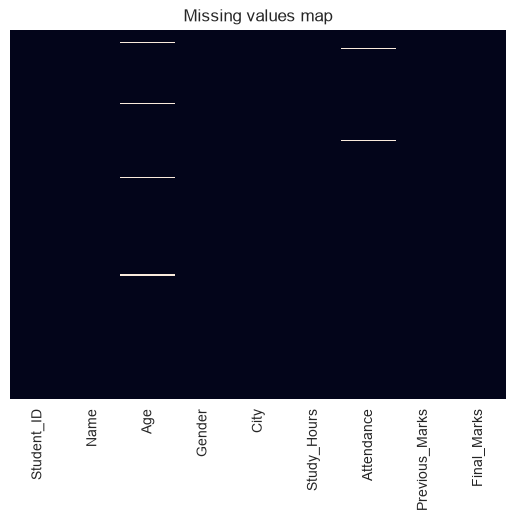

In [39]:
# Visual: missing-value map (bright = missing)
sns.heatmap(raw.drop(columns="Age_missing").isnull(), cbar=False, yticklabels=False)
plt.title("Missing values map")
plt.show()

---
# 2️⃣0️⃣ Analyze Relationships

Create specific questions. Instead of *"Let's make charts."* ask *"Does study time relate to marks?"*

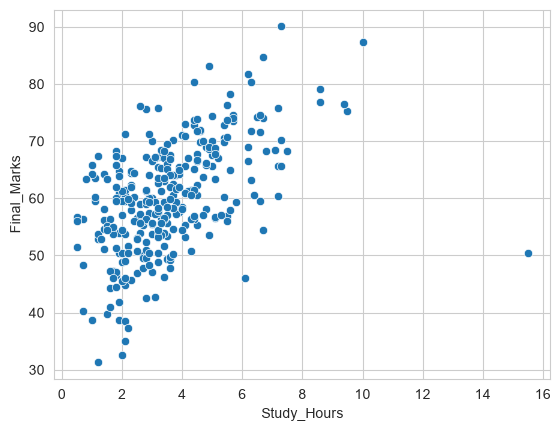

In [40]:
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Marks"
)

plt.show()

---
# ⭐ Question-Driven EDA

```text
Question → Choose Analysis → Choose Statistic / Visualization → Analyze Result → Write Insight
```

**Example — Question:** *Does attendance relate to marks?* → Visualization: **Scatter Plot** → Analysis: look for a relationship → Insight: describe what the data shows.

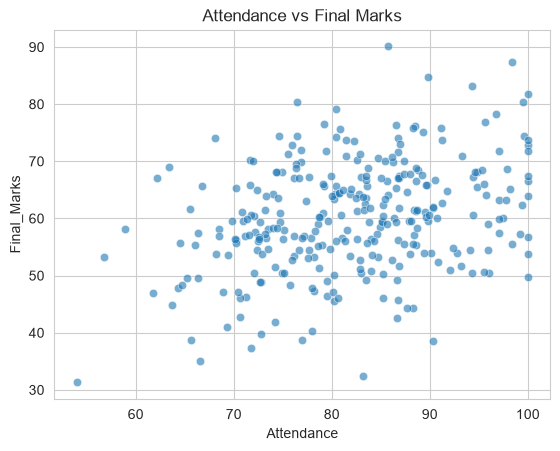

Correlation = 0.33


In [41]:
# Question: Does attendance relate to marks?
sns.scatterplot(data=df, x="Attendance", y="Final_Marks", alpha=0.6)
plt.title("Attendance vs Final Marks")
plt.show()

r = df["Attendance"].corr(df["Final_Marks"])
print(f"Correlation = {r:.2f}")

---
# 📝 2️⃣1️⃣ Write Insights

Don't stop after creating charts. Write what you learned:

```text
📌 Insight:
Students with higher attendance generally show higher marks in this dataset,
although the relationship is not perfect and does not establish causation.
```

This is what turns visualization into **analysis**. A helpful habit — a template for each finding:

```text
📌 Question   📊 Visualization   🔎 Observation   💡 Insight
```

Numbers in an insight should come from the data, so let Python fill them in (and re-run the notebook if the data changes):

In [42]:
def describe_strength(r):
    a = abs(r)
    return "strong" if a >= 0.6 else "moderate" if a >= 0.3 else "weak"

for col in ["Study_Hours", "Attendance", "Previous_Marks"]:
    r = df[col].corr(df["Final_Marks"])
    direction = "positive" if r > 0 else "negative"
    print(f"📌 {col} shows a {describe_strength(r)} {direction} association with Final_Marks "
          f"(r = {r:.2f}); this is an association, not proof of causation.")

📌 Study_Hours shows a moderate positive association with Final_Marks (r = 0.52); this is an association, not proof of causation.
📌 Attendance shows a moderate positive association with Final_Marks (r = 0.33); this is an association, not proof of causation.
📌 Previous_Marks shows a moderate positive association with Final_Marks (r = 0.58); this is an association, not proof of causation.


---
# 📊 2️⃣2️⃣ EDA Visualization Guide

| Question                                      | Recommended Visualization |
| --------------------------------------------- | ------------------------- |
| What does one numerical variable look like?   | Histogram                 |
| Is the distribution smooth?                   | KDE                       |
| Are there outliers?                           | Box Plot                  |
| How many categories exist?                    | Count Plot                |
| Relationship between two numerical variables? | Scatter Plot              |
| Trend over time?                              | Line Plot                 |
| Compare categories?                           | Bar Plot                  |
| Compare distributions?                        | Box/Violin Plot           |
| Many numerical variables?                     | Pair Plot                 |
| Correlation between variables?                | Heatmap                   |
| Category vs category?                         | Count/Crosstab/Heatmap    |

---
# 🧠 2️⃣3️⃣ EDA Statistics

* **Central tendency:** Mean, Median, Mode
* **Spread:** Range, Variance, Standard Deviation, IQR
* **Position:** Percentiles, Quartiles
* **Relationship:** Correlation, Covariance

In [43]:
s = df["Final_Marks"]

print("Mean      :", round(s.mean(), 2))
print("Median    :", round(s.median(), 2))
print("Mode      :", s.mode().iloc[0])
print("Range     :", round(s.max() - s.min(), 2))
print("Variance  :", round(s.var(), 2))
print("Std Dev   :", round(s.std(), 2))
print("IQR       :", round(s.quantile(.75) - s.quantile(.25), 2))
print("Percentiles (10/50/90):", s.quantile([.1, .5, .9]).round(1).tolist())
print("Covariance (Study_Hours, Final_Marks):", round(df["Study_Hours"].cov(df["Final_Marks"]), 2))
print("Correlation(Study_Hours, Final_Marks):", round(df["Study_Hours"].corr(df["Final_Marks"]), 3))

Mean      : 60.24
Median    : 60.0
Mode      : 50.5
Range     : 58.8
Variance  : 93.5
Std Dev   : 9.67
IQR       : 12.7
Percentiles (10/50/90): [48.2, 60.0, 72.0]
Covariance (Study_Hours, Final_Marks): 9.21
Correlation(Study_Hours, Final_Marks): 0.516


---
# 🧩 2️⃣4️⃣ EDA with NumPy + Pandas + Matplotlib + Seaborn

```text
NumPy → Numerical Operations → Pandas → Data Manipulation → Data Cleaning
→ Matplotlib → General Visualization → Seaborn → Statistical Visualization → EDA → Insights
```

This is the point where your previous libraries start working together — the notebook you just read used all four.

---
# 🏢 2️⃣5️⃣ Real-World EDA Examples

* 🛒 **E-Commerce** — Which products sell the most? Which category generates the most revenue? Does price affect quantity sold? Which customers spend the most?
* 💰 **Finance** — How are returns distributed? Which assets move together? Are there unusual returns? How does volatility change?
* 🏥 **Healthcare** — How is age distributed? Are some groups more represented? Which variables are associated with an outcome? Are there unusual measurements?
* 🎓 **Education** — Does attendance relate to marks? Does study time relate to performance? Which subjects have lower scores? Are there performance differences between groups?

---
# 🤖 2️⃣6️⃣ EDA Before Machine Learning

```text
Dataset → Data Understanding → Data Cleaning → EDA → Feature Understanding
→ Feature Engineering → Train/Test Split → Machine Learning
```

EDA helps you understand what you're feeding into the model.

---
# ⚠️ 2️⃣7️⃣ Important ML EDA Rule — Avoid Data Leakage

When EDA is used to build a predictive ML pipeline, be careful about using information from the **test set** to make preprocessing or feature-selection decisions.

```text
Raw Dataset → Basic Understanding → Train / Validation / Test Split
→ Learn preprocessing from Training Data → Apply to Validation/Test → Model
```

A concrete example — filling missing values with the mean:

In [44]:
ml = raw.drop(columns=["Age_missing"]).drop_duplicates().copy()
ml.loc[ml["Age"] > 100, "Age"] = np.nan

# 1) split FIRST
test = ml.sample(frac=0.2, random_state=0)
train = ml.drop(test.index)

# 2) learn the statistic from TRAIN only
age_median_train = train["Age"].median()

# 3) apply the same value to both
train["Age"] = train["Age"].fillna(age_median_train)
test["Age"] = test["Age"].fillna(age_median_train)     # NOT test["Age"].median()!

print("Train rows:", len(train), "| Test rows:", len(test))
print("Median learned from train only:", age_median_train)

Train rows: 240 | Test rows: 60
Median learned from train only: 21.0


❌ **Leakage would be:** computing `ml['Age'].median()` on the *whole* dataset (train + test) before splitting — the test data would then influence preprocessing. (Later, scikit-learn's `train_test_split` and `Pipeline` do this safely for you.) Also watch for **leaky features** — columns that contain the answer or are only known after the outcome.

---
# 🔁 2️⃣8️⃣ EDA Is Iterative

```text
Explore → Find Problem → Clean → Explore Again → Find Another Problem → Clean Again
→ Analyze → Discover Pattern → Ask New Question → Analyze Again
```

> **EDA is an investigation, not a checklist you execute once and forget.**

In this notebook we already did it: describe → noticed `Age = 250` → cleaned → re-explored.

---
# ❌ Common EDA Mistakes

1. **Making random charts** — don't create 20 charts without questions.
2. **Only looking at averages** — mean alone doesn't describe the whole dataset.
3. **Ignoring distributions** — two groups can have the same mean but different distributions.
4. **Ignoring outliers** — they can strongly affect statistics and models.
5. **Assuming correlation means causation.**
6. **Ignoring categorical variables** — not everything important is numerical.
7. **Not writing insights** — a chart without interpretation is incomplete.
8. **Treating every unusual value as an error** — investigate first.

Mistake #3 in action — same mean, different story:

Means: 59.9 60.3


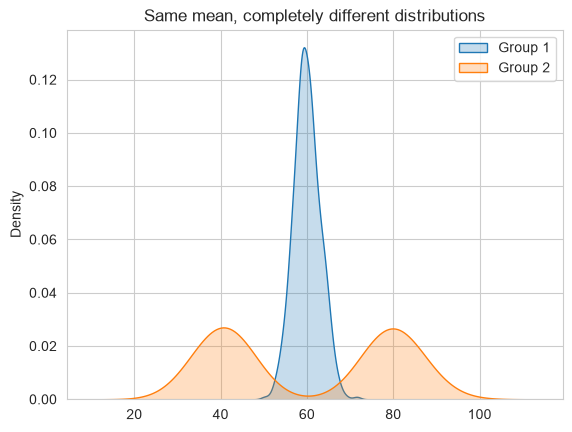

In [45]:
g1 = rng.normal(60, 3, 500)
g2 = np.concatenate([rng.normal(40, 5, 250), rng.normal(80, 5, 250)])
print("Means:", round(g1.mean(), 1), round(g2.mean(), 1))

sns.kdeplot(g1, label="Group 1", fill=True)
sns.kdeplot(g2, label="Group 2", fill=True)
plt.legend(); plt.title("Same mean, completely different distributions")
plt.show()

---
# ⭐ Best EDA Tips

* 💡 **Start with questions** — *What do I want to know?*
* 💡 **Understand every column** — name, meaning, type, expected values, units.
* 💡 **Use statistics + visualization** — `Statistics → Numbers`, `Visualization → Patterns`.
* 💡 **Compare groups** — not "average salary = 60,000" but average salary by department / experience / city.
* 💡 **Look at distributions** — *What does the data actually look like?*
* 💡 **Write down findings** — 📌 Question · 📊 Visualization · 🔎 Observation · 💡 Insight.

---
# 🧰 A Reusable First-Look Function

Everything from the "understand → inspect → quality" steps in one helper you can run on any new CSV:

In [46]:
def first_look(d, target=None):
    print("=" * 60)
    print(f"Rows: {d.shape[0]:,} | Columns: {d.shape[1]} | Duplicates: {d.duplicated().sum()}")
    print("=" * 60)

    info = pd.DataFrame({
        "dtype": d.dtypes.astype(str),
        "missing_%": (d.isnull().mean() * 100).round(1),
        "unique": d.nunique(),
        "example": d.iloc[0],
    })
    display(info)

    numeric = d.select_dtypes("number")
    display(numeric.describe().T.round(2))

    cats = d.select_dtypes(exclude="number")
    for c in cats.columns:
        if d[c].nunique() <= 10:
            print(f"\n{c}:"); print(d[c].value_counts().head(10))

    if target and target in numeric:
        print(f"\nCorrelation with {target}:")
        print(numeric.corr()[target].drop(target).sort_values(ascending=False).round(3))

first_look(df.drop(columns=["Student_ID"]), target="Final_Marks")

Rows: 300 | Columns: 8 | Duplicates: 0


,dtype,missing_%,unique,example
Name,str,0.0,300,Student_1
Age,float64,0.0,8,24.0
Gender,str,0.0,2,Male
City,str,0.0,4,Peshawar
Study_Hours,float64,0.0,69,1.1
Attendance,float64,0.0,195,83.5
Previous_Marks,float64,0.0,221,82.6
Final_Marks,float64,0.0,197,63.5


,count,mean,std,min,25%,50%,75%,max
Age,300.0,21.53,2.26,18.0,20.00,21.00,23.00,25.0
Study_Hours,300.0,3.59,1.85,0.5,2.28,3.30,4.50,15.5
Attendance,300.0,82.08,9.46,54.0,74.90,82.55,88.43,100.0
Previous_Marks,300.0,62.73,12.82,15.0,53.78,62.60,71.82,100.0
Final_Marks,300.0,60.24,9.67,31.3,54.30,60.00,67.00,90.1



Gender:
Gender
Female    154
Male      146
Name: count, dtype: int64

City:
City
Islamabad    126
Lahore        88
Karachi       60
Peshawar      26
Name: count, dtype: int64

Correlation with Final_Marks:
Previous_Marks    0.582
Study_Hours       0.516
Attendance        0.328
Age              -0.109
Name: Final_Marks, dtype: float64


---
# 🧪 Mini Project — Complete EDA on Student Performance

Dataset columns: `Student_ID, Name, Age, Gender, Study_Hours, Attendance, Previous_Marks, Final_Marks, City` — exactly the generated `students.csv` above. We start again from the **raw** file and follow the README's 8 steps.

### Step 1 — Understand

In [47]:
p = pd.read_csv("students.csv")
print(p.shape)
display(p.head())
p.info()
display(p.describe().round(2))

(302, 9)


,Student_ID,Name,Age,Gender,City,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,1,Student_1,24.0,Male,Peshawar,1.1,83.5,82.6,63.5
1,2,Student_2,20.0,Male,Islamabad,1.9,79.1,54.7,61.0
2,3,Student_3,23.0,Female,Lahore,3.2,94.4,77.8,67.3
3,4,Student_4,19.0,Female,Peshawar,1.2,82.9,70.2,52.8
4,5,Student_5,25.0,Male,Lahore,0.5,74.2,60.3,51.5


<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      302 non-null    int64  
 1   Name            302 non-null    str    
 2   Age             298 non-null    float64
 3   Gender          302 non-null    str    
 4   City            302 non-null    str    
 5   Study_Hours     302 non-null    float64
 6   Attendance      300 non-null    float64
 7   Previous_Marks  302 non-null    float64
 8   Final_Marks     302 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 21.4 KB


,Student_ID,Age,Study_Hours,Attendance,Previous_Marks,Final_Marks
count,302.00,298.00,302.00,300.00,302.00,302.00
mean,149.51,22.31,3.58,82.08,62.77,60.26
std,87.30,13.43,1.85,9.46,12.84,9.64
min,1.00,18.00,0.50,54.00,15.00,31.30
25%,74.25,20.00,2.20,74.90,53.80,54.40
50%,149.50,21.50,3.30,82.55,62.60,60.05
75%,224.75,23.00,4.50,88.43,71.88,67.00
max,300.00,250.00,15.50,100.00,100.00,90.10


### Step 2 — Data Quality

In [48]:
print(p.isnull().sum())
print("Duplicates:", p.duplicated().sum())

p = p.drop_duplicates().reset_index(drop=True)
p.loc[p["Age"] > 100, "Age"] = np.nan
p["Age"] = p["Age"].fillna(p["Age"].median())
p["Attendance"] = p["Attendance"].fillna(p["Attendance"].median())
print("After cleaning ->", p.shape, "| missing:", p.isnull().sum().sum())

Student_ID        0
Name              0
Age               4
Gender            0
City              0
Study_Hours       0
Attendance        2
Previous_Marks    0
Final_Marks       0
dtype: int64
Duplicates: 2
After cleaning -> (300, 9) | missing: 0


### Step 3 — Univariate Analysis (Age, Study Hours, Attendance, Final Marks, Gender, City)

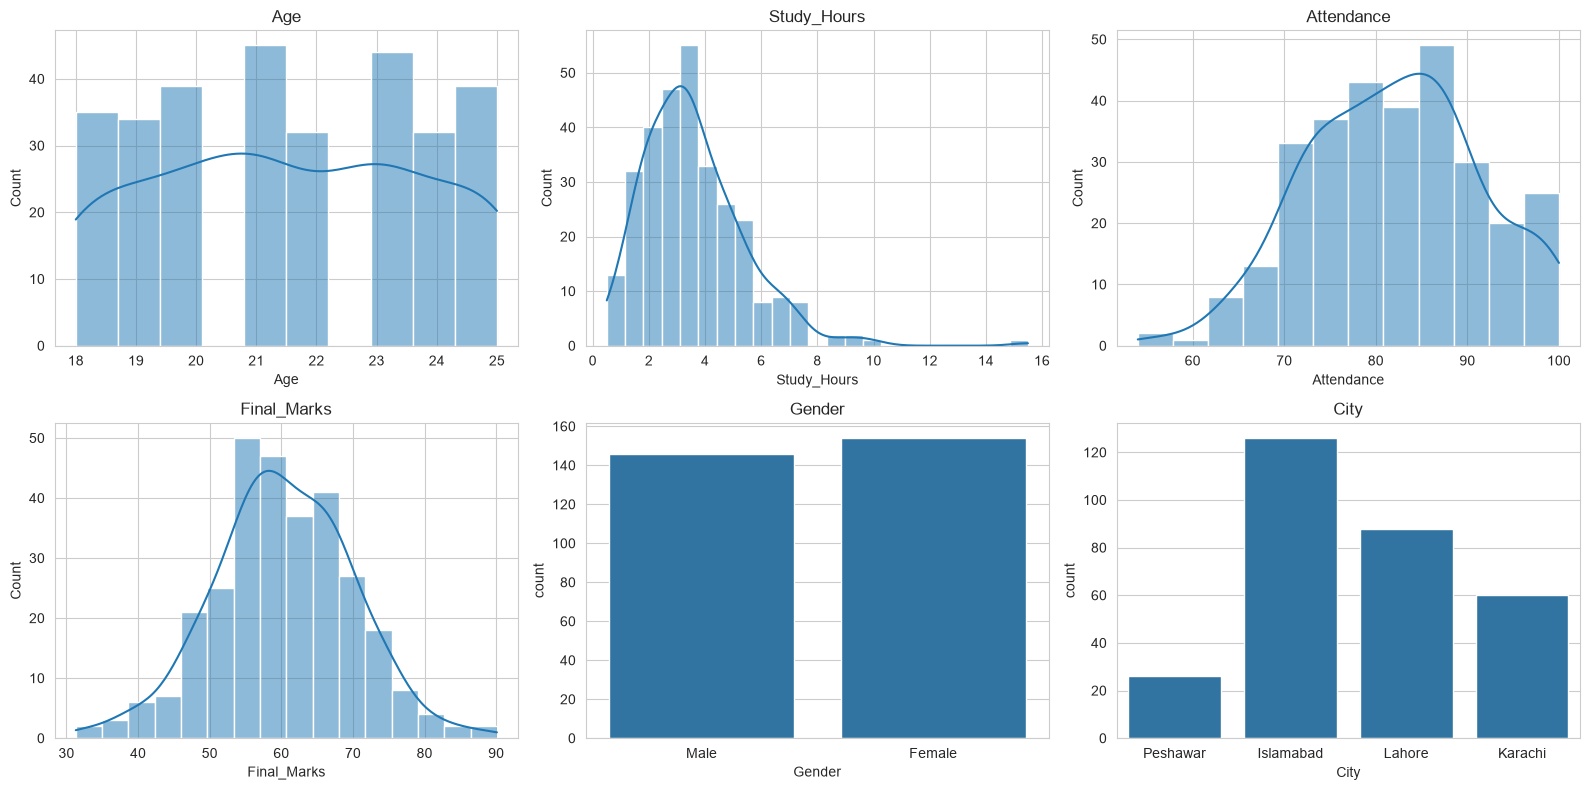

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel()[:4], ["Age", "Study_Hours", "Attendance", "Final_Marks"]):
    sns.histplot(p[col], kde=True, ax=ax); ax.set_title(col)
sns.countplot(data=p, x="Gender", ax=axes[1, 1]); axes[1, 1].set_title("Gender")
sns.countplot(data=p, x="City", ax=axes[1, 2]); axes[1, 2].set_title("City")
plt.tight_layout(); plt.show()

### Step 4 — Bivariate Analysis

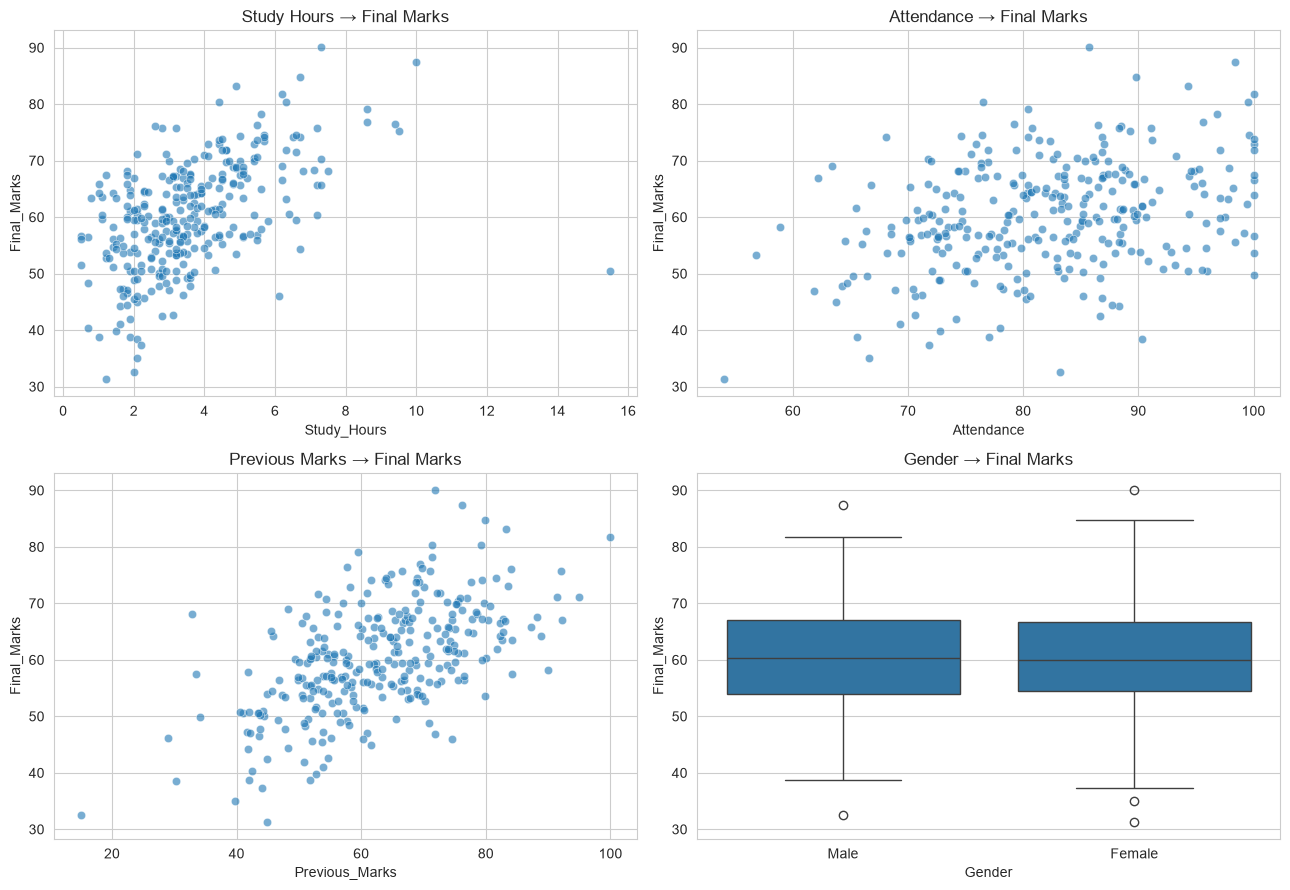

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.scatterplot(data=p, x="Study_Hours", y="Final_Marks", alpha=0.6, ax=axes[0, 0]);    axes[0, 0].set_title("Study Hours → Final Marks")
sns.scatterplot(data=p, x="Attendance", y="Final_Marks", alpha=0.6, ax=axes[0, 1]);     axes[0, 1].set_title("Attendance → Final Marks")
sns.scatterplot(data=p, x="Previous_Marks", y="Final_Marks", alpha=0.6, ax=axes[1, 0]); axes[1, 0].set_title("Previous Marks → Final Marks")
sns.boxplot(data=p, x="Gender", y="Final_Marks", ax=axes[1, 1]);                         axes[1, 1].set_title("Gender → Final Marks")
plt.tight_layout(); plt.show()

### Step 5 — Multivariate Analysis

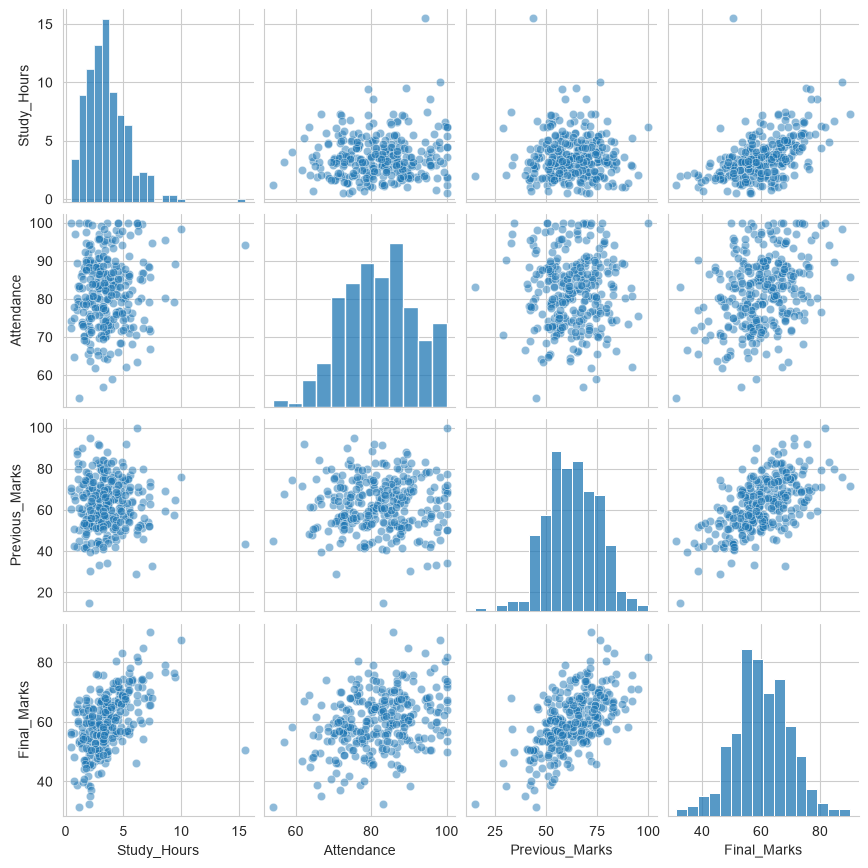

In [51]:
sns.pairplot(p[["Study_Hours", "Attendance", "Previous_Marks", "Final_Marks"]], plot_kws={"alpha": 0.5}, height=2.2)
plt.show()

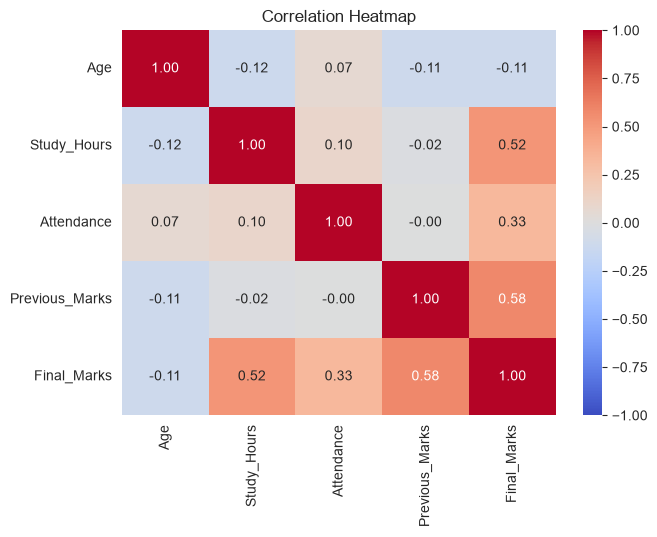

count        mean       
Gender    Female Male Female   Male
City                               
Islamabad     71   55  59.40  60.41
Karachi       27   33  60.37  57.44
Lahore        44   44  61.74  61.88
Peshawar      12   14  58.36  62.04

In [52]:
plt.figure(figsize=(7, 5))
sns.heatmap(p[["Age", "Study_Hours", "Attendance", "Previous_Marks", "Final_Marks"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap"); plt.show()

display(p.groupby(["City", "Gender"])["Final_Marks"].agg(["count", "mean"]).round(2).unstack())

### Step 6 — Outliers

In [53]:
outlier_summary(p, ["Age", "Study_Hours", "Attendance", "Final_Marks"])

,column,lower,upper,n_outliers
0,Age,15.5,27.5,0
1,Study_Hours,-1.1,7.8,6
2,Attendance,54.6,108.7,1
3,Final_Marks,35.2,86.1,5


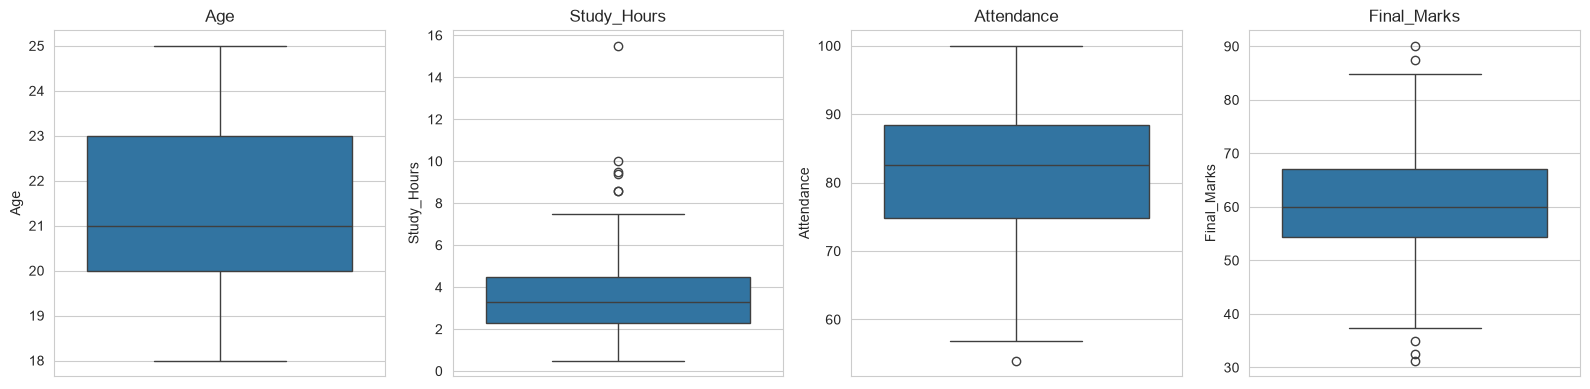

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["Age", "Study_Hours", "Attendance", "Final_Marks"]):
    sns.boxplot(y=p[col], ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

### Step 7 — Write Insights (generated from the data, then interpreted by you)

In [55]:
r = p[["Study_Hours", "Attendance", "Previous_Marks", "Age"]].corrwith(p["Final_Marks"]).sort_values(ascending=False)
gm = p.groupby("Gender")["Final_Marks"].mean()
cm = p.groupby("City")["Final_Marks"].mean().sort_values(ascending=False)
out = outlier_summary(p, ["Study_Hours", "Attendance", "Final_Marks"]).set_index("column")["n_outliers"]

insights = [
    f"Average final marks are {p['Final_Marks'].mean():.1f} (median {p['Final_Marks'].median():.1f}), so the distribution is roughly symmetric.",
    f"{r.abs().idxmax()} has the strongest association with Final_Marks (r = {r[r.abs().idxmax()]:.2f}).",
    f"Study_Hours shows a {describe_strength(r['Study_Hours'])} positive association with Final_Marks (r = {r['Study_Hours']:.2f}); it does not by itself prove causation.",
    f"Attendance shows a {describe_strength(r['Attendance'])} positive association with Final_Marks (r = {r['Attendance']:.2f}).",
    f"Age shows a {describe_strength(r['Age'])} association with Final_Marks (r = {r['Age']:.2f}).",
    f"Mean marks differ by only {abs(gm.max() - gm.min()):.1f} points between genders — no meaningful gap in this sample.",
    f"{cm.index[0]} has the highest average marks ({cm.iloc[0]:.1f}) and {cm.index[-1]} the lowest ({cm.iloc[-1]:.1f}); check group sizes before reading too much into it.",
    f"Study_Hours has {out['Study_Hours']} IQR outlier(s), Attendance {out['Attendance']}, Final_Marks {out['Final_Marks']}; the 15.5 study-hours value should be verified with the data owner.",
    f"Data quality: {len(raw) - len(p)} duplicate rows removed, {int((raw['Age'] > 100).sum())} impossible age treated as missing, {int(raw[['Age', 'Attendance']].isnull().sum().sum()) + int((raw['Age'] > 100).sum())} missing values filled with medians.",
]
for i, text in enumerate(insights, 1):
    print(f"📌 Finding {i}: {text}\n")

📌 Finding 1: Average final marks are 60.2 (median 60.0), so the distribution is roughly symmetric.

📌 Finding 2: Previous_Marks has the strongest association with Final_Marks (r = 0.58).

📌 Finding 3: Study_Hours shows a moderate positive association with Final_Marks (r = 0.52); it does not by itself prove causation.

📌 Finding 4: Attendance shows a moderate positive association with Final_Marks (r = 0.33).

📌 Finding 5: Age shows a weak association with Final_Marks (r = -0.11).

📌 Finding 6: Mean marks differ by only 0.2 points between genders — no meaningful gap in this sample.

📌 Finding 7: Lahore has the highest average marks (61.8) and Karachi the lowest (58.8); check group sizes before reading too much into it.

📌 Finding 8: Study_Hours has 6 IQR outlier(s), Attendance 1, Final_Marks 5; the 15.5 study-hours value should be verified with the data owner.

📌 Finding 9: Data quality: 2 duplicate rows removed, 1 impossible age treated as missing, 7 missing values filled with medians.


✍️ **Your turn:** add 2–3 findings of your own in a new cell — and replace any generic claim above (e.g. *"roughly symmetric"*) if the numbers on your run disagree. Insights must always follow the data, not the other way round.

### Step 8 — Final Report

In [56]:
print("=" * 62)
print("FINAL EDA REPORT — STUDENT PERFORMANCE")
print("=" * 62)
print(f"\n1. DATASET SUMMARY\n   {p.shape[0]} students, {p.shape[1]} columns; target = Final_Marks")
print(f"\n2. DATA QUALITY FINDINGS\n   Raw rows: {len(raw)} -> cleaned rows: {len(p)}; missing after cleaning: {p.isnull().sum().sum()}")
print("\n3. STATISTICAL FINDINGS")
print(p[["Study_Hours", "Attendance", "Previous_Marks", "Final_Marks"]].describe().loc[["mean", "50%", "std"]].round(2).to_string())
print("\n4./5. VISUALIZATION FINDINGS & IMPORTANT RELATIONSHIPS")
print(r.round(2).to_string())
print("\n6. OUTLIERS")
print(out.to_string())
print("\n7. FINAL INSIGHTS")
for t in insights[:3]:
    print("  •", t)

FINAL EDA REPORT — STUDENT PERFORMANCE

1. DATASET SUMMARY
   300 students, 9 columns; target = Final_Marks

2. DATA QUALITY FINDINGS
   Raw rows: 302 -> cleaned rows: 300; missing after cleaning: 0

3. STATISTICAL FINDINGS
      Study_Hours  Attendance  Previous_Marks  Final_Marks
mean         3.59       82.08           62.73        60.24
50%          3.30       82.55           62.60        60.00
std          1.85        9.46           12.82         9.67

4./5. VISUALIZATION FINDINGS & IMPORTANT RELATIONSHIPS
Previous_Marks    0.58
Study_Hours       0.52
Attendance        0.33
Age              -0.11

6. OUTLIERS
column
Study_Hours    6
Attendance     1
Final_Marks    5

7. FINAL INSIGHTS
  • Average final marks are 60.2 (median 60.0), so the distribution is roughly symmetric.
  • Previous_Marks has the strongest association with Final_Marks (r = 0.58).
  • Study_Hours shows a moderate positive association with Final_Marks (r = 0.52); it does not by itself prove causation.


---
# 🎯 Learning Goals

After completing **Class 22 — EDA**, you should understand:

- [ ] What EDA means and why it is important
- [ ] The complete EDA workflow
- [ ] Understanding a dataset · Dataset inspection · Data quality analysis
- [ ] Univariate · Bivariate · Multivariate analysis
- [ ] Numerical · Categorical · Distribution analysis
- [ ] Outlier · Correlation · Group · Missing-value analysis
- [ ] Statistics in EDA · Visualization selection
- [ ] Question-driven EDA · Writing insights
- [ ] EDA with Pandas / Matplotlib / Seaborn
- [ ] EDA before Machine Learning · Data leakage awareness
- [ ] Iterative EDA · A complete EDA project

---
# ✏️ Practice

Write your solutions below each prompt.

**Practice 1 — Unknown CSV.** Load any CSV you like (or `students.csv`) and run `first_look()`. Write down 5 questions the output raises.

**Practice 2 — Univariate.** Pick one numerical and one categorical column. Describe each with statistics AND a chart, then write one insight for each.

**Practice 3 — Bivariate.** Test the question *"Does previous performance relate to final performance?"* with the full Question → Visualization → Observation → Insight template.

**Practice 4 — Groups.** Compare Final_Marks across City using `count`, `mean`, `median`, `std`. Does the ranking change if you use the median instead of the mean?

**Practice 5 — Outliers.** Find the IQR outliers in `Study_Hours`. Decide whether to remove, cap or keep them, and justify it in one sentence.

**Practice 6 — Leakage.** Write code that splits the data 80/20 and standardizes `Study_Hours` (z-score) using the mean/std learned only from the training set.

---
# ❓ Interview Questions

### Beginner
1. What is EDA?
2. Why is EDA important?
3. What is the purpose of `df.describe()`?
4. What is univariate analysis?
5. What is bivariate analysis?
6. What is multivariate analysis?
7. Why do we visualize data?

### Intermediate
8. How do you find missing values?
9. How do you detect outliers?
10. What is correlation?
11. What is the difference between correlation and causation?
12. What is the purpose of a correlation heatmap?
13. When would you use a box plot?
14. When would you use a scatter plot?
15. How do you analyze categorical variables?
16. Why are distributions important?
17. Why is EDA iterative?

### Practical
18. You receive a completely unknown CSV. What do you do first?
19. How would you investigate the relationship between two numerical variables?
20. How would you compare salaries between departments?
21. How would you investigate an unusual value?
22. How would you find the most important relationships in a dataset?
23. How would you present your EDA findings to a non-technical person?

---
# 📁 Folder Structure

```text
02-Data-Science/
├── README.md
├── 01-NumPy/          (README.md, class17.ipynb)
├── 02-Pandas/         (README.md, class18.ipynb)
├── 03-Matplotlib/     (README.md, class19.ipynb)
├── 04-Seaborn/        (README.md, class20.ipynb)
├── 05-Data-Cleaning/  (README.md, class21.ipynb)
└── 06-EDA-Workflow/   (README.md, class22.ipynb)
```

---
# 🧠 The EDA Formula to Remember

```text
             EDA
      ┌───────┼────────┐
   Inspect  Analyze  Visualize
      └───────┼────────┘
          Find Patterns → Ask Questions → Generate Insights
```

### The most important habit:

> **Don't ask "Which chart should I make?" first. Ask "What do I want to know about this data?"**

Then choose the statistic or visualization that helps answer that question.